In [1]:
import torch
import gc
from diffusers import AutoPipelineForInpainting
from PIL import Image
import matplotlib.pyplot as plt

c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [2]:
# 1. Налаштування
models_to_test = {
    "SD 1.5": "runwayml/stable-diffusion-inpainting",
    "SD 2.0": "sd2-community/stable-diffusion-2-inpainting",
    "SDXL": "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"
}

# Шляхи до ваших файлів (з вашого коду)
init_img_path = "imgs/5.jpg"
mask_img_path = "inpaint_mask.png"
prompt = "empty background, high quality"
negative_prompt = "bad anatomy, blurry, artifacts, low res"
seed = 42 # Фіксуємо seed для об'єктивного порівняння

# 2. Підготовка зображень
init_image = Image.open(init_img_path).convert("RGB")
mask_image = Image.open(mask_img_path).convert("RGB")

# Для SDXL краще використовувати роздільну здатність 1024x1024, 
# але для чесного порівняння з SD 1.5/2.0 приведемо до 512x512
target_size = (512, 512)
init_image = init_image.resize(target_size)
mask_image = mask_image.resize(target_size)

results = {}


Завантаження та генерація для: SD 1.5 (runwayml/stable-diffusion-inpainting)


c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  8.08it/s]


Готово для SD 1.5. Пам'ять очищено.

Завантаження та генерація для: SD 2.0 (sd2-community/stable-diffusion-2-inpainting)


100%|██████████| 30/30 [00:03<00:00,  8.01it/s]


Готово для SD 2.0. Пам'ять очищено.

Завантаження та генерація для: SDXL (diffusers/stable-diffusion-xl-1.0-inpainting-0.1)


100%|██████████| 29/29 [00:15<00:00,  1.84it/s]


Готово для SDXL. Пам'ять очищено.


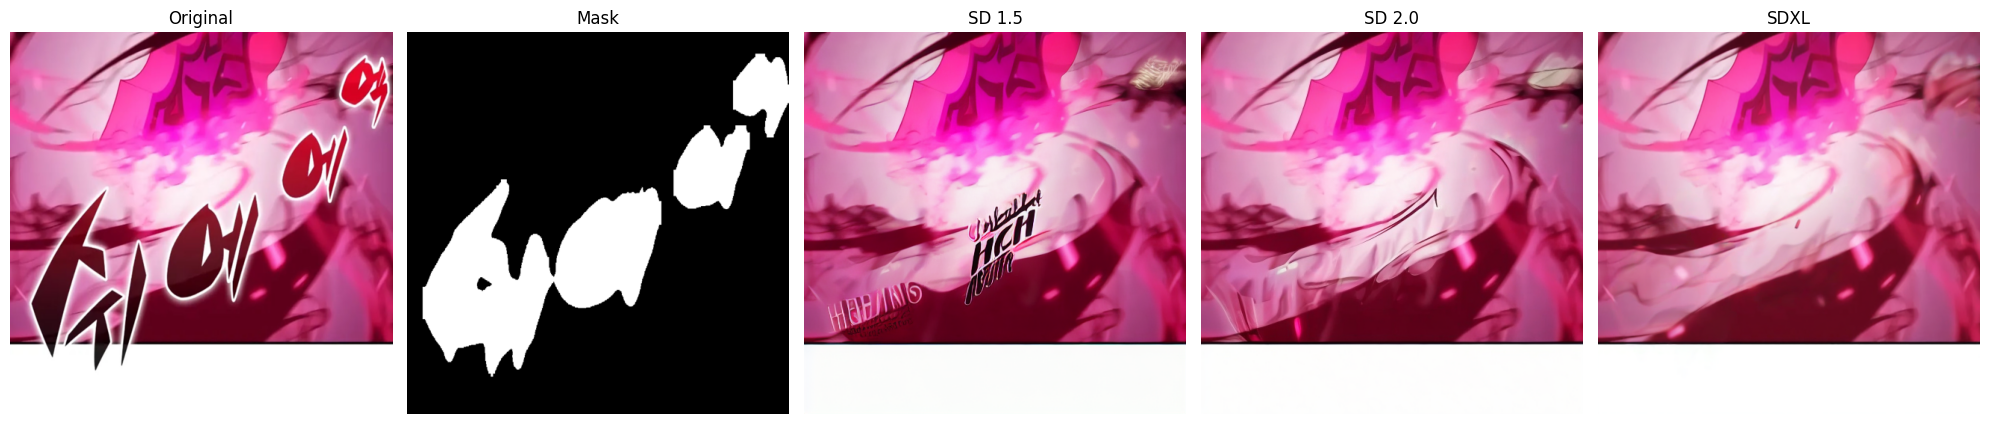

In [3]:
# 3. Цикл порівняння
for model_name, model_id in models_to_test.items():
    print(f"\nЗавантаження та генерація для: {model_name} ({model_id})")
    
    # Завантажуємо пайплайн
    pipe = AutoPipelineForInpainting.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        variant="fp16" # Використовуємо полегшені ваги для економії VRAM
    )
    
    # Оптимізація для 12 GB VRAM
    pipe.enable_model_cpu_offload() 
    # Вимикаємо safety checker для прискорення
    if hasattr(pipe, 'safety_checker') and pipe.safety_checker is not None:
        pipe.safety_checker = None
        pipe.requires_safety_checker = False

    # Генератор для фіксованого результату
    generator = torch.Generator(device="cuda").manual_seed(seed)
    
    # Генерація
    with torch.autocast("cuda"):
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=init_image,
            mask_image=mask_image,
            num_inference_steps=30,
            generator=generator
        ).images[0]
        
    results[model_name] = image
    image.save(f"result_{model_name.replace(' ', '_')}.png")
    
    # 4. Очищення пам'яті ПЕРЕД наступною моделлю
    del pipe
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Готово для {model_name}. Пам'ять очищено.")

# 5. Візуалізація результатів
fig, axes = plt.subplots(1, len(results) + 2, figsize=(20, 5))

# Оригінал та маска
axes[0].imshow(init_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_image)
axes[1].set_title("Mask")
axes[1].axis("off")

# Результати моделей
for ax, (model_name, img) in zip(axes[2:], results.items()):
    ax.imshow(img)
    ax.set_title(model_name)
    ax.axis("off")

plt.tight_layout()
plt.savefig("comparison_grid.png")
plt.show()

In [ ]:
from huggingface_hub import login

# Замініть 'hf_ВАШ_ТОКЕН_ТУТ' на скопійований токен
login(token="HF_TOKEN")

In [ ]:
import torch
from diffusers import DiffusionPipeline
from diffusers.utils import load_image

# switch to "mps" for apple devices
pipe = DiffusionPipeline.from_pretrained("black-forest-labs/FLUX.2-klein-4B", 
                                         dtype=torch.bfloat16, 
                                         device_map="cuda")


# Обов'язкова оптимізація для 12 GB VRAM
pipe.enable_model_cpu_offload()

# 3. Генерація
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,       # Передаємо оригінальне зображення
    mask_image=mask_image,  # Передаємо маску
    height=1024,
    width=1024,
    guidance_scale=1.0,     # Для distilled-моделей FLUX.2 залишаємо 1.0
    num_inference_steps=4,  # 4 кроки — стандарт для цієї моделі
    generator=torch.Generator(device='cuda').manual_seed(0)
).images[0]


Keyword arguments {'dtype': torch.bfloat16} are not expected by Flux2KleinPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 5/5 [00:22<00:00,  4.52s/it]


TypeError: Flux2KleinPipeline.__call__() got an unexpected keyword argument 'mask_image'

In [ ]:
plt.imshow(image)